In [1]:
# Student Name: Amir Gharghabi
# Student ID: 810102217
# HW: 3
# Q: 8

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Specify the path to the data file
file_path = "data/housePricing.csv"
# Read the data into a pandas DataFrame
df = pd.read_csv(file_path)
# Display basic information about the DataFrame
print("DataFrame Information:")
df.info()
print("_______________________________________________")
# Display summary statistics of the DataFrame
print("\nDataFrame Descriptive Statistics:")
df.describe()

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [3]:
# Check for missing values
missing_values = df.isnull().sum()

# Print titles of columns with more than 0 missing values
columns_with_missing = missing_values[missing_values > 0].index
for column in columns_with_missing:
    print(f"Column '{column}' has {missing_values[column]} missing values.")
    
# Handle missing values (example: fill with mean)
#df.fillna(df.mean(), inplace=True)

Column 'LotFrontage' has 259 missing values.
Column 'Alley' has 1369 missing values.
Column 'MasVnrType' has 8 missing values.
Column 'MasVnrArea' has 8 missing values.
Column 'BsmtQual' has 37 missing values.
Column 'BsmtCond' has 37 missing values.
Column 'BsmtExposure' has 38 missing values.
Column 'BsmtFinType1' has 37 missing values.
Column 'BsmtFinType2' has 38 missing values.
Column 'Electrical' has 1 missing values.
Column 'FireplaceQu' has 690 missing values.
Column 'GarageType' has 81 missing values.
Column 'GarageYrBlt' has 81 missing values.
Column 'GarageFinish' has 81 missing values.
Column 'GarageQual' has 81 missing values.
Column 'GarageCond' has 81 missing values.
Column 'PoolQC' has 1453 missing values.
Column 'Fence' has 1179 missing values.
Column 'MiscFeature' has 1406 missing values.


In [4]:
df_copy = df
df = df.drop(['PoolQC', 'Fence', 'MiscFeature', 'Alley', 'FireplaceQu'], axis=1)

In [5]:
constant_columns = df.columns[df.nunique() == 1]

# Display the columns with constant values
print("Columns with constant values:")
print(constant_columns)

Columns with constant values:
Index([], dtype='object')


In [6]:
binary_columns = df.columns[df.nunique() <=20]
# Iterate through binary columns and replace values
for column in binary_columns:
    unique_values = df[column].unique()    
    # Map the unique values to 0 and 1
    df[column] = df[column].replace({unique_values[0]: 0, unique_values[1]: 1})

print("Binary Columns:")
print(binary_columns)

Binary Columns:
Index(['MSSubClass', 'MSZoning', 'Street', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir',
       'Electrical', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'GarageType', 'GarageFinish', 'GarageCars',
       'GarageQual', 'GarageCond', 'PavedDrive', '3SsnPorch', 'PoolArea',
       'MoSold', 'YrSold', 'SaleType', 'SaleCondition'],
      dtype='object')


In [7]:
numerical_columns = df.select_dtypes(include='number').columns
binary_columns = df.columns[df.nunique() == 2]

# Replace missing values in numerical columns with the mean
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())

# Replace missing values in binary columns with the mode
for column in binary_columns:
    mode_value = df[column].mode().iloc[0]
    df[column] = df[column].fillna(mode_value)

# Display the DataFrame after replacement
print("DataFrame after replacing missing values:")
print(df)

DataFrame after replacing missing values:
        Id  MSSubClass MSZoning  LotFrontage  LotArea  Street LotShape  \
0        1           0        0         65.0     8450       0        0   
1        2           1        0         80.0     9600       0        0   
2        3           0        0         68.0    11250       0        1   
3        4          70        0         60.0     9550       0        1   
4        5           0        0         84.0    14260       0        1   
...    ...         ...      ...          ...      ...     ...      ...   
1455  1456           0        0         62.0     7917       0        0   
1456  1457           1        0         85.0    13175       0        0   
1457  1458          70        0         66.0     9042       0        0   
1458  1459           1        0         68.0     9717       0        0   
1459  1460           1        0         75.0     9937       0        0   

     LandContour  Utilities LotConfig  ... EnclosedPorch 3SsnPorch  \

In [9]:
df.describe()


,Id,MSSubClass,LotFrontage,LotArea,Street,Utilities,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,37.634247,70.049958,10516.828082,0.004110,0.000685,3.289041,2.418493,1971.267808,1984.865753,...,94.244521,46.660274,21.954110,3.191096,15.060959,2.408904,43.489041,5.691781,1137.674658,180921.195890
std,421.610009,52.222600,22.024023,9981.264932,0.063996,0.026171,2.937553,3.051904,30.202904,20.645407,...,125.338794,66.256028,61.119149,28.120539,55.757415,37.899247,496.123024,3.374429,995.217218,79442.502883
min,1.000000,0.000000,21.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,1872.000000,1950.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,365.750000,1.000000,60.000000,7553.500000,0.000000,0.000000,1.000000,0.000000,1954.000000,1967.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,129975.000000
50%,730.500000,1.000000,70.049958,9478.500000,0.000000,0.000000,4.000000,0.000000,1973.000000,1994.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2006.000000,163000.000000
75%,1095.250000,70.000000,79.000000,11601.500000,0.000000,0.000000,5.000000,6.000000,2000.000000,2004.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,1.000000,1.000000,10.000000,9.000000,2010.000000,2010.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [10]:
# Print all values of the "GarageQual" column
print("All values of GarageQual column:")
print(df['GarageQual'])

All values of GarageQual column:
0       0
1       0
2       0
3       0
4       0
       ..
1455    0
1456    0
1457    0
1458    0
1459    0
Name: GarageQual, Length: 1460, dtype: object


In [8]:
X = df.drop(['SalePrice'], axis=1)
y = df['SalePrice']  # Target variable
# Display the first few rows of X and y for verification
print("Features (X):")
print(X.head())

print("\nLable(y):")
print(y.head())

Features (X):
   Id  MSSubClass MSZoning  LotFrontage  LotArea  Street LotShape LandContour  \
0   1           0        0         65.0     8450       0        0           0   
1   2           1        0         80.0     9600       0        0           0   
2   3           0        0         68.0    11250       0        1           0   
3   4          70        0         60.0     9550       0        1           0   
4   5           0        0         84.0    14260       0        1           0   

   Utilities LotConfig  ... OpenPorchSF EnclosedPorch 3SsnPorch ScreenPorch  \
0          0         0  ...          61             0         0           0   
1          0         1  ...           0             0         0           0   
2          0         0  ...          42             0         0           0   
3          0    Corner  ...          35           272         0           0   
4          0         1  ...          84             0         0           0   

  PoolArea MiscVal  MoSo

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [38]:
categorical_columns = X.select_dtypes(include='object').columns

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

# Standardize the numerical features
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X_encoded)

X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y, test_size=0.3, random_state=101)

# Split the remaining data into test and validation sets
X_test, X_validation, y_test, y_validation = train_test_split(X_temp, y_temp, test_size=0.5, random_state=101)
# Initialize SelectKBest with f_regression scoring function
k_best = SelectKBest(score_func=f_regression, k='all')
K_20 = SelectKBest(score_func=f_regression, k='20')
K_40 = SelectKBest(score_func=f_regression, k='40')
K_60 = SelectKBest(score_func=f_regression, k='60')


# Fit and transform on the training set
X_train_selected = k_best.fit_transform(X_train, y_train)

# Get the indices of the selected features
selected_indices = k_best.get_support(indices=True)

# Get the names of the selected features
selected_features = X_train.columns[selected_indices]

# Display the selected feature names
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'Street', 'Utilities',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       ...
       'SaleType_Con', 'SaleType_ConLD', 'SaleType_ConLI', 'SaleType_ConLw',
       'SaleType_Oth', 'SaleCondition_1', 'SaleCondition_AdjLand',
       'SaleCondition_Alloca', 'SaleCondition_Family',
       'SaleCondition_Partial'],
      dtype='object', length=233)


G:\UT\Term1\ML\Python\virtual_env\my_env\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:289: RuntimeWarning: invalid value encountered in true_divide
  correlation_coefficient /= X_norms


In [13]:
non_numerical_columns = X_train.select_dtypes(exclude=['number']).columns

if len(non_numerical_columns) > 0:
    print("X_train has non-numerical values in the following columns:")
    print(non_numerical_columns)
else:
    print("X_train contains only numerical values.")

X_train contains only numerical values.


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.svm import SVR


In [41]:
svm_model_linear = SVR(kernel='linear')
svm_model_linear.fit(X_train_selected, y_train)

# Make predictions on the test set
y_pred_svm_linear = svm_model_linear.predict(k_best.transform(X_test))
print("done")

done


In [42]:
y_pred_val = svm_model_linear.predict(k_best.transform(X_validation))


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score


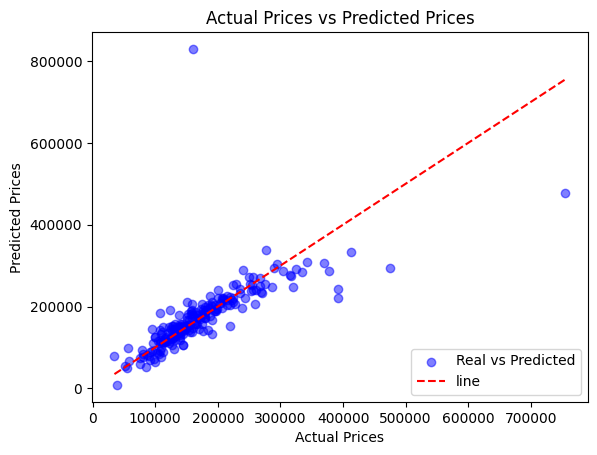

In [23]:
plt.scatter(y_test, y_pred_svm_linear, alpha=0.5, c='blue', label='Real vs Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', label='line')  # Diagonal line for perfect prediction
plt.title('Actual Prices vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()

In [33]:
y_pred_test = svm_model_linear.predict(k_best.transform(X_test))

# Evaluate the model on the test set
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print the metrics for the test set
print("\nTest Set Evaluation for k = 'all':")
print("\n_______________________")
print(f'Mean Squared Error (MSE): {mse_test}')
print(f'R-squared (R2) Score: {r2_test}')


Test Set Evaluation for k = 'all':

_______________________
Mean Squared Error (MSE): 3380119014.540934
R-squared (R2) Score: 0.48408093690748355


In [34]:
y_pred_validation = svm_model_linear.predict(k_best.transform(X_validation))

# Evaluate the model on the test set
mse_test = mean_squared_error(y_validation, y_pred_validation)
r2_test = r2_score(y_validation, y_pred_validation)

# Print the metrics for the test set
print("\nValidation Set Evaluation for k = 'all':")
print("\n_______________________")
print(f'Mean Squared Error (MSE): {mse_test}')
print(f'R-squared (R2) Score: {r2_test}')


Validation Set Evaluation for k = 'all':

_______________________
Mean Squared Error (MSE): 1318943207.655494
R-squared (R2) Score: 0.7785611505688756
